# Detecting Phishing Websites Using Random Forest Regression

## EDA and Data Cleaning

In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.offline as pyo
import plotly.graph_objs as go
import plotly.express as px

In [6]:
train = pd.read_csv(r'C:\Users\HP\KaggleDatasets\train_academya.csv')
test = pd.read_csv(r'C:\Users\HP\KaggleDatasets\test_academya.csv')

In [7]:
train.shape

(132660, 29)

In [8]:
test.shape

(70000, 28)

In [9]:
train.head()

,id,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,domain_registration_length,favicon,...,on_mouseover,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,page_rank,google_index,links_pointing_to_page,Result
0,70005,No,44,Yes,Yes,6,Yes,1,1.156395,No,...,No,NaN,No,Yes,1,Yes,2.247106,Yes,2,Phishing
1,70006,Yes,53,Yes,Yes,6,No,1,1.278885,Yes,...,Yes,Enabled,Yes,Yes,2,Yes,2.675417,No,1,Phishing
2,70007,Yes,49,Yes,No,7,Yes,3,1.515832,NaN,...,No,Disabled,No,No,1,Yes,2.680063,Yes,2,Legitimate
3,70008,Yes,40,No,Yes,7,No,1,1.707852,No,...,Yes,NaN,No,Yes,2,No,2.493129,No,0,Phishing
4,70009,NaN,51,No,NaN,7,No,1,1.396846,No,...,Yes,Disabled,No,Yes,1,No,2.133598,Yes,2,Legitimate


In [10]:
test.head()

,id,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,domain_registration_length,favicon,...,redirect,on_mouseover,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,page_rank,google_index,links_pointing_to_page
0,1,Yes,50,Yes,Yes,7,No,1,1.838718,NaN,...,5,No,NaN,NaN,Yes,5,No,2.479710,NaN,0
1,2,Yes,41,Yes,NaN,7,No,6,1.637320,No,...,1,Yes,Enabled,No,No,3,No,2.635774,NaN,0
2,3,No,47,Yes,No,6,No,1,1.334754,Yes,...,5,Yes,Disabled,No,No,5,Yes,2.104309,No,0
3,4,Yes,50,Yes,Yes,6,No,1,1.763969,Yes,...,1,NaN,Enabled,No,No,2,No,2.625191,NaN,2
4,5,No,49,No,Yes,6,No,8,1.799184,Yes,...,1,Yes,Disabled,Yes,Yes,5,No,2.131189,Yes,2


In [12]:
missing_columns = train.columns[train.isnull().any()]
print(missing_columns)

Index(['having_ip_address', 'shortining_service', 'having_at_symbol',
       'prefix_suffix', 'favicon', 'port', 'https_token', 'sfh',
       'submitting_to_email', 'abnormal_url', 'on_mouseover', 'rightclick',
       'popupwindow', 'iframe', 'dnsrecord', 'google_index'],
      dtype='object')


In [16]:
missing_columns = test.columns[test.isnull().any()]
print(missing_columns)

Index(['having_ip_address', 'shortining_service', 'having_at_symbol',
       'prefix_suffix', 'favicon', 'port', 'https_token', 'sfh',
       'submitting_to_email', 'abnormal_url', 'on_mouseover', 'rightclick',
       'popupwindow', 'iframe', 'dnsrecord', 'google_index'],
      dtype='object')


In [20]:
missing_rows = train[train.isnull().any(axis=1)]
missing_rows

,id,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,domain_registration_length,favicon,...,on_mouseover,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,page_rank,google_index,links_pointing_to_page,Result
0,70005,No,44,Yes,Yes,6,Yes,1,1.156395,No,...,No,NaN,No,Yes,1,Yes,2.247106,Yes,2,Phishing
2,70007,Yes,49,Yes,No,7,Yes,3,1.515832,NaN,...,No,Disabled,No,No,1,Yes,2.680063,Yes,2,Legitimate
3,70008,Yes,40,No,Yes,7,No,1,1.707852,No,...,Yes,NaN,No,Yes,2,No,2.493129,No,0,Phishing
4,70009,NaN,51,No,NaN,7,No,1,1.396846,No,...,Yes,Disabled,No,Yes,1,No,2.133598,Yes,2,Legitimate
5,70010,No,44,Yes,Yes,7,Yes,3,1.316276,No,...,No,Enabled,NaN,No,2,Yes,2.569674,Yes,2,Phishing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132655,202660,Yes,52,Yes,Yes,7,No,1,1.721079,NaN,...,Yes,Disabled,NaN,Yes,2,Yes,2.063996,Yes,0,Legitimate
132656,202661,Yes,47,Yes,Yes,6,NaN,7,1.217118,Yes,...,Yes,Disabled,Yes,Yes,5,Yes,2.592432,Yes,0,Legitimate
132657,202662,Yes,40,Yes,NaN,6,No,3,1.759058,NaN,...,Yes,Disabled,Yes,Yes,3,Yes,2.201574,Yes,0,Legitimate
132658,202663,Yes,41,Yes,Yes,7,No,1,1.856783,Yes,...,Yes,Disabled,NaN,Yes,5,Yes,2.628736,Yes,0,Legitimate


In [30]:
train = train.apply(lambda x: x.fillna(x.mode()[0]))

In [32]:
missing_columns = train.columns[train.isnull().any()]
print(missing_columns)

Index([], dtype='object')


In [34]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132660 entries, 0 to 132659
Data columns (total 29 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id                          132660 non-null  int64  
 1   having_ip_address           132660 non-null  object 
 2   url_length                  132660 non-null  int64  
 3   shortining_service          132660 non-null  object 
 4   having_at_symbol            132660 non-null  object 
 5   double_slash_redirecting    132660 non-null  int64  
 6   prefix_suffix               132660 non-null  object 
 7   having_sub_domain           132660 non-null  int64  
 8   domain_registration_length  132660 non-null  float64
 9   favicon                     132660 non-null  object 
 10  port                        132660 non-null  object 
 11  https_token                 132660 non-null  object 
 12  request_url                 132660 non-null  int64  
 13  url_of_anchor 

In [38]:
train.describe()

,id,url_length,double_slash_redirecting,having_sub_domain,domain_registration_length,request_url,url_of_anchor,links_in_tags,redirect,age_of_domain,page_rank,links_pointing_to_page
count,132660.000000,132660.000000,132660.000000,132660.000000,132660.000000,132660.000000,132660.000000,132660.000000,132660.000000,132660.000000,132660.000000,132660.000000
mean,136334.500000,46.482625,6.500460,3.088218,1.550194,15.498801,25.005179,12.996653,3.820368,2.999600,2.350183,0.834909
std,38295.787693,4.030564,0.500002,2.781874,0.259340,3.450062,3.162222,2.002438,1.952085,1.417522,0.201635,0.777316
min,70005.000000,40.000000,6.000000,1.000000,1.100001,10.000000,20.000000,10.000000,1.000000,1.000000,2.000006,0.000000
25%,103169.750000,43.000000,6.000000,1.000000,1.326145,12.000000,22.000000,11.000000,1.000000,2.000000,2.175482,0.000000
50%,136334.500000,46.000000,7.000000,1.000000,1.550711,15.000000,25.000000,13.000000,4.000000,3.000000,2.349830,1.000000
75%,169499.250000,50.000000,7.000000,5.000000,1.774446,18.000000,28.000000,15.000000,5.000000,4.000000,2.524631,1.000000
max,202664.000000,53.000000,7.000000,9.000000,1.999990,21.000000,30.000000,16.000000,6.000000,5.000000,2.699998,2.000000


In [42]:
unique_categories = train['sfh'].dropna().unique()

unique_categories

array(['Suspecious', 'High', 'Low'], dtype=object)

In [44]:
category_counts = train['sfh'].value_counts(dropna=True)
category_counts

sfh
Low           77961
Suspecious    32679
High          22020
Name: count, dtype: int64

In [46]:
test = test.apply(lambda x: x.fillna(x.mode()[0]))

In [48]:
missing_columns = test.columns[test.isnull().any()]
print(missing_columns)

Index([], dtype='object')


## Pre Processing

### Label Encoder to change categorical data

In [54]:
from sklearn.preprocessing import LabelEncoder

In [66]:
categorical_cols = train.select_dtypes(include=['object']).columns
categorical_cols = categorical_cols.drop('Result', errors='ignore')

In [68]:
label_encoders = {}  # Store encoders
for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])  # Fit & transform train
    if col in test.columns:  # Ensure column exists in test set
        test[col] = test[col].apply(lambda x: x if x in le.classes_ else "Unknown")
        test[col] = le.transform(test[col])  # Transform test using same encoder
    label_encoders[col] = le 

In [70]:
for col in categorical_cols:
    test[col] = test[col].apply(lambda x: x if x in label_encoders[col].classes_ else "Unknown")
    test[col] = label_encoders[col].transform(test[col])

In [72]:
train.head()

,id,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,domain_registration_length,favicon,...,on_mouseover,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,page_rank,google_index,links_pointing_to_page,Result
0,70005,0,44,1,1,6,1,1,1.156395,0,...,0,0,0,1,1,1,2.247106,1,2,1
1,70006,1,53,1,1,6,0,1,1.278885,1,...,1,1,1,1,2,1,2.675417,0,1,1
2,70007,1,49,1,0,7,1,3,1.515832,1,...,0,0,0,0,1,1,2.680063,1,2,0
3,70008,1,40,0,1,7,0,1,1.707852,0,...,1,0,0,1,2,0,2.493129,0,0,1
4,70009,1,51,0,1,7,0,1,1.396846,0,...,1,0,0,1,1,0,2.133598,1,2,0


In [74]:
test.head()

,id,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,domain_registration_length,favicon,...,redirect,on_mouseover,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,page_rank,google_index,links_pointing_to_page
0,1,1,50,1,1,7,0,1,1.838718,1,...,5,0,0,1,1,5,0,2.479710,1,0
1,2,1,41,1,1,7,0,6,1.637320,0,...,1,1,1,0,0,3,0,2.635774,1,0
2,3,0,47,1,0,6,0,1,1.334754,1,...,5,1,0,0,0,5,1,2.104309,0,0
3,4,1,50,1,1,6,0,1,1.763969,1,...,1,1,1,0,0,2,0,2.625191,1,2
4,5,0,49,0,1,6,0,8,1.799184,1,...,1,1,0,1,1,5,0,2.131189,1,2


### Drop low-Correlated features

In [77]:
corr_matrix = train.corr()

In [79]:
low_corr_features = corr_matrix['Result'][abs(corr_matrix['Result']) < 0.01].index.tolist()

In [81]:
train.drop(columns=low_corr_features, inplace=True)
test.drop(columns=[col for col in low_corr_features if col in test.columns], inplace=True)

print(f"Dropped {len(low_corr_features)} low-correlation features.")

Dropped 12 low-correlation features.


In [83]:
train.head()

,id,having_ip_address,having_at_symbol,prefix_suffix,having_sub_domain,port,sfh,submitting_to_email,abnormal_url,redirect,on_mouseover,rightclick,popupwindow,iframe,dnsrecord,google_index,Result
0,70005,0,1,1,1,1,2,1,1,1,0,0,0,1,1,1,1
1,70006,1,1,0,1,1,0,1,1,6,1,1,1,1,1,0,1
2,70007,1,0,1,3,0,1,1,0,6,0,0,0,0,1,1,0
3,70008,1,1,0,1,1,1,1,1,4,1,0,0,1,0,0,1
4,70009,1,1,0,1,0,1,1,1,1,1,0,0,1,0,1,0


In [85]:
test.head()

,id,having_ip_address,having_at_symbol,prefix_suffix,having_sub_domain,port,sfh,submitting_to_email,abnormal_url,redirect,on_mouseover,rightclick,popupwindow,iframe,dnsrecord,google_index
0,1,1,1,0,1,1,1,1,1,5,0,0,1,1,0,1
1,2,1,1,0,6,1,1,1,1,1,1,1,0,0,0,1
2,3,0,0,0,1,1,1,0,1,5,1,0,0,0,1,0
3,4,1,1,0,1,1,1,0,1,1,1,1,0,0,0,1
4,5,0,1,0,8,1,0,1,0,1,1,0,1,1,0,1


In [87]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132660 entries, 0 to 132659
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   id                   132660 non-null  int64
 1   having_ip_address    132660 non-null  int32
 2   having_at_symbol     132660 non-null  int32
 3   prefix_suffix        132660 non-null  int32
 4   having_sub_domain    132660 non-null  int64
 5   port                 132660 non-null  int32
 6   sfh                  132660 non-null  int32
 7   submitting_to_email  132660 non-null  int32
 8   abnormal_url         132660 non-null  int32
 9   redirect             132660 non-null  int64
 10  on_mouseover         132660 non-null  int32
 11  rightclick           132660 non-null  int32
 12  popupwindow          132660 non-null  int32
 13  iframe               132660 non-null  int32
 14  dnsrecord            132660 non-null  int32
 15  google_index         132660 non-null  int32
 16  Re

In [89]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id                   70000 non-null  int64
 1   having_ip_address    70000 non-null  int32
 2   having_at_symbol     70000 non-null  int32
 3   prefix_suffix        70000 non-null  int32
 4   having_sub_domain    70000 non-null  int64
 5   port                 70000 non-null  int32
 6   sfh                  70000 non-null  int32
 7   submitting_to_email  70000 non-null  int32
 8   abnormal_url         70000 non-null  int32
 9   redirect             70000 non-null  int64
 10  on_mouseover         70000 non-null  int32
 11  rightclick           70000 non-null  int32
 12  popupwindow          70000 non-null  int32
 13  iframe               70000 non-null  int32
 14  dnsrecord            70000 non-null  int32
 15  google_index         70000 non-null  int32
dtypes: int32(13), int64(3)

### Split into Validation set

In [92]:
from sklearn.model_selection import train_test_split

In [94]:
# Separate features (X) and target (y)
X = train.drop(columns=['Result'])
y = train['Result']

In [96]:
# Train-Validation Split (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [98]:
print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {test.shape}")

Train: (106128, 16), Validation: (26532, 16), Test: (70000, 16)


### SMOTEENN For handling oversampling/undersampling

In [101]:
from imblearn.combine import SMOTEENN
from collections import Counter

In [104]:
# Apply SMOTEENN only to the training set
smoteenn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smoteenn.fit_resample(X_train, y_train)

In [106]:
# Check new class distribution
print("Before SMOTEENN:", Counter(y_train))  # Original class distribution
print("After SMOTEENN:", Counter(y_train_resampled))  # Balanced class distribution

# Final dataset shapes
print(f"Resampled Train: {X_train_resampled.shape}, Validation: {X_val.shape}, Test: {test.shape}")

Before SMOTEENN: Counter({1: 55362, 0: 50766})
After SMOTEENN: Counter({0: 9067, 1: 8049})
Resampled Train: (17116, 16), Validation: (26532, 16), Test: (70000, 16)


### SMOTE because SMOTEENN is inefective

In [112]:
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter

In [118]:
knn = KNeighborsClassifier(n_jobs=-1)  # Use all CPU cores

smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_resampled))

After SMOTE: Counter({1: 55362, 0: 55362})


In [172]:
print("Training class distribution after SMOTE:", Counter(y_train_resampled))
print("Validation class distribution:", Counter(y_val))  # Check if y_val is imbalanced

Training class distribution after SMOTE: Counter({0: 9067, 1: 8049})
Validation class distribution: Counter({1: 13841, 0: 12691})


### Resampling the Validation dataset

In [152]:
from sklearn.utils import resample

# Separate classes
val_0 = X_val[y_val == 0]
val_1 = X_val[y_val == 1]

# Downsample class 1 to match class 0
val_1_downsampled, y_val_1_downsampled = resample(
    val_1, y_val[y_val == 1],
    replace=False,  # No oversampling
    n_samples=len(val_0),  # Match class 0
    random_state=42
)

# Merge balanced validation set
X_val_balanced = pd.concat([val_0, val_1_downsampled])
y_val_balanced = pd.concat([y_val[y_val == 0], y_val_1_downsampled])

print("Balanced Validation Distribution:", Counter(y_val_balanced))

Balanced Validation Distribution: Counter({0: 12691, 1: 12691})


## Modelling

In [156]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [158]:
from sklearn.metrics import classification_report, confusion_matrix

In [174]:
# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_resampled),
    y=y_train_resampled
)
class_weight_dict = dict(enumerate(class_weights))

# Build Improved Neural Network
model = Sequential([
    keras.Input(shape=(X_train_resampled.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification output
])

# Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model with Class Weights
history = model.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict  # Apply class weights
)

# Evaluate Model
val_preds = model.predict(X_val)
y_val_preds_classes = (val_preds > 0.5).astype(int).flatten()

# Print classification report
from sklearn.metrics import classification_report
print(classification_report(y_val, y_val_preds_classes))

Epoch 1/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5658 - loss: 0.8011 - val_accuracy: 0.5215 - val_loss: 0.7432
Epoch 2/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5597 - loss: 0.7276 - val_accuracy: 0.5215 - val_loss: 0.7203
Epoch 3/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5770 - loss: 0.7074 - val_accuracy: 0.5248 - val_loss: 0.7080
Epoch 4/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5844 - loss: 0.6989 - val_accuracy: 0.5242 - val_loss: 0.7041
Epoch 5/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5725 - loss: 0.6924 - val_accuracy: 0.5245 - val_loss: 0.7112
Epoch 6/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5842 - loss: 0.6835 - val_accuracy: 0.5249 - val_loss: 0.7062
Epoch 7/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5809 - loss: 0.6840 - val_accuracy: 0.5236 - val_loss: 0.7043
Epoch 8/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5856 - loss: 0.6845 - val_accu

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



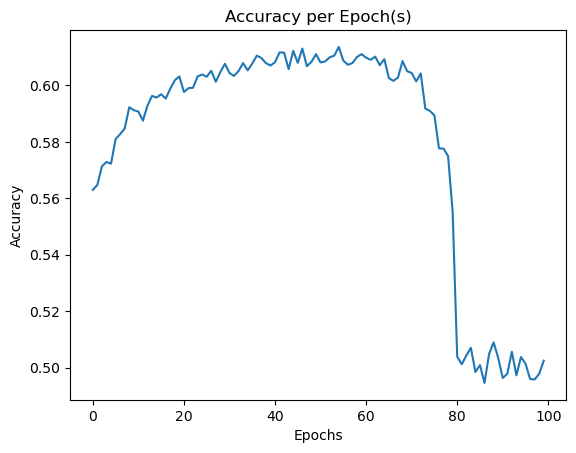

In [175]:
plt.plot(history.history['accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy per Epoch(s)")
plt.show()